# Passport strength by country: the Middle East first, then the world

**How many destinations can the holder of each Middle East passport enter without arranging a visa before travel, and how does the region compare with the rest of the world?**

Data: Henley Passport Index 2026, 199 passports scored against 227 destinations. The full April 2026 table is read from two publishers. July 2026 figures come from the Henley & Partners release and news reports of it. This notebook reads the raw files, checks them, recomputes the headline figures and asserts that they equal the output of `scripts/build_data.py`.

## 1. Load the raw files

The April table is kept as two readings, one per publisher. July figures are kept one row per figure per document.

In [1]:
import os
if os.path.basename(os.getcwd()) == "notebooks":
    os.chdir("..")  # run from the project folder
import pandas as pd
pd.set_option("display.width", 170)
wiki = pd.read_csv("data/raw/henley_2026_april_reading_wikipedia.csv")
rows = []
for line in open("data/raw/henley_2026_april_reading_packzup.txt", encoding="utf-8"):
    score, rank, names = line.strip().split("|")
    rows += [(n, int(rank), int(score)) for n in names.split(";")]
pack = pd.DataFrame(rows, columns=["country", "rank", "visa_free_score"])
pack["country"] = pack.country.replace({"Sao Tome and Principe": "São Tomé and Príncipe", "Cote d'Ivoire": "Ivory Coast"})
readings = pd.read_csv("data/raw/henley_2026_edition_readings.csv", dtype={"edition": str})
ref = pd.read_csv("data/raw/country_reference.csv")
print("rows:", len(wiki), len(pack), "| edition readings:", len(readings), "| reference:", len(ref))
wiki.head()

rows: 199 199 | edition readings: 108 | reference: 199


,rank,country,visa_free_score
0,1,Singapore,192
1,2,Japan,187
2,2,South Korea,187
3,2,United Arab Emirates,187
4,3,Sweden,186


## 2. Data checks

Row count, missing values, duplicates, value range, and whether the two readings agree.

In [2]:
print("missing:", int(wiki.isna().sum().sum()), int(pack.isna().sum().sum()))
print("duplicate passports:", int(wiki.country.duplicated().sum()), int(pack.country.duplicated().sum()))
print("score range:", wiki.visa_free_score.min(), "to", wiki.visa_free_score.max(), "of 227 destinations")
both = wiki.merge(pack, on="country", suffixes=("_wikipedia", "_packzup"), how="outer", indicator=True)
print("passports in one reading only:", int((both._merge != "both").sum()))
both[(both.visa_free_score_wikipedia != both.visa_free_score_packzup) | (both.rank_wikipedia != both.rank_packzup)].drop(columns="_merge")

missing: 0 0
duplicate passports: 0 0
score range: 23 to 192 of 227 destinations
passports in one reading only: 0


,rank_wikipedia,country,visa_free_score_wikipedia,rank_packzup,visa_free_score_packzup
13,97,Bangladesh,34,95,36


One row differs. Wikipedia prints Bangladesh at 34 with rank 97, which is out of order in its own table (it sits above Nepal at 35). Packzup prints 36 at rank 95, the rank missing between 94 and 96, and a third article (What's On, 12 May 2026) also prints 36. The analysis uses 36 and marks the row `publishers-differ`.

In [3]:
apr = pack.rename(columns={"visa_free_score": "score_apr_2026", "rank": "rank_printed"}).copy()
# The index gives tied passports the same rank and does not skip ranks, so the rank is the dense rank of the score.
apr["dense_rank"] = apr.score_apr_2026.rank(method="dense", ascending=False).astype(int)
print("printed rank equals dense rank of the score for", int((apr.dense_rank == apr.rank_printed).sum()), "of", len(apr))
assert (apr.dense_rank == apr.rank_printed).all()
print("distinct scores:", apr.score_apr_2026.nunique(), "| lowest rank number:", apr.rank_printed.max())

printed rank equals dense rank of the score for 199 of 199
distinct scores: 101 | lowest rank number: 101


## 3. Do published figures match the table?

April figures printed in three news articles must equal the table. The published totals are tested too.

In [4]:
a = readings[readings.edition == "2026-04"].merge(apr, on="country", how="left")
score_ok = a[a.visa_free_score.notna()]
rank_ok = a[a["rank"].notna()]
print("April scores printed in articles:", len(score_ok), "| equal to the table:", int((score_ok.visa_free_score == score_ok.score_apr_2026).sum()))
print("April ranks printed in articles: ", len(rank_ok), "| equal to the table:", int((rank_ok["rank"] == rank_ok.rank_printed).sum()))
world_mean = round(apr.score_apr_2026.mean(), 2)
print("world mean of the April table:", world_mean, "| published average (July, rounded): 108")
print("gap between highest and lowest in April:", apr.score_apr_2026.max() - apr.score_apr_2026.min(), "| published: 169")
assert abs(world_mean - 108) <= 1 and apr.score_apr_2026.max() - apr.score_apr_2026.min() == 169

April scores printed in articles: 41 | equal to the table: 41
April ranks printed in articles:  45 | equal to the table: 45
world mean of the April table: 107.21 | published average (July, rounded): 108
gap between highest and lowest in April: 169 | published: 169


## 4. July 2026 figures

A July score is used only if every document that prints it gives the same number. The count of documents is kept next to each figure.

In [5]:
j = readings[(readings.edition == "2026-07") & readings.visa_free_score.notna()]
jul = j.groupby("country").agg(score_jul_2026=("visa_free_score", "first"), distinct_scores=("visa_free_score", "nunique"),
                               documents=("source_id", "nunique")).reset_index()
assert (jul.distinct_scores == 1).all(), "July documents disagree"
tidy = pd.read_csv("data/processed/passport_tidy.csv")
me = tidy[tidy.region == "Middle East"]
print("July figures found for", int(me.score_jul_2026.notna().sum()), "of the 20 Middle East passports")
print(me.jul_check.value_counts().to_string())
me[["country", "sub_region", "score_apr_2026", "rank_apr_2026", "score_jul_2026", "rank_jul_2026", "change_apr_to_jul", "jul_check"]]

July figures found for 18 of the 20 Middle East passports
jul_check
one-publisher     8
3-publishers      5
2-publishers      4
no-july-figure    2
5-publishers      1


,country,sub_region,score_apr_2026,rank_apr_2026,score_jul_2026,rank_jul_2026,change_apr_to_jul,jul_check
0,United Arab Emirates,Gulf,187,2,188.0,2.0,1.0,5-publishers
1,Israel,Levant and Iraq,166,16,NaN,18.0,NaN,no-july-figure
2,Turkey,"Iran, Turkey and Yemen",113,44,NaN,NaN,NaN,no-july-figure
3,Qatar,Gulf,111,45,112.0,48.0,1.0,3-publishers
4,Kuwait,Gulf,96,47,97.0,51.0,1.0,3-publishers
5,Bahrain,Gulf,87,51,88.0,55.0,1.0,3-publishers
6,Saudi Arabia,Gulf,87,51,91.0,54.0,4.0,3-publishers
7,Oman,Gulf,84,54,85.0,58.0,1.0,3-publishers
8,Morocco,North Africa,71,63,71.0,67.0,0.0,one-publisher
9,Tunisia,North Africa,66,68,66.0,71.0,0.0,one-publisher


## 5. The Gulf

Scores and ranks in April and July, and how many passports score higher than each one.

In [6]:
gulf = tidy[tidy.sub_region == "Gulf"].sort_values("score_jul_2026", ascending=False).copy()
gulf["higher_scores_apr"] = [int((tidy.score_apr_2026 > s).sum()) for s in gulf.score_apr_2026]
print("Gulf mean, April:", round(gulf.score_apr_2026.mean(), 2), "| July:", round(gulf.score_jul_2026.mean(), 2))
print("Gulf passports above the published world average of 108 in July:", int((gulf.score_jul_2026 > 108).sum()), "of 6")
print("scores that rose from April to July:", int((gulf.change_apr_to_jul > 0).sum()), "| ranks that fell:", int((gulf.rank_jul_2026 > gulf.rank_apr_2026).sum()))
gulf[["country", "score_apr_2026", "score_jul_2026", "change_apr_to_jul", "rank_apr_2026", "rank_jul_2026", "higher_scores_apr"]]

Gulf mean, April: 108.67 | July: 110.17
Gulf passports above the published world average of 108 in July: 2 of 6
scores that rose from April to July: 6 | ranks that fell: 5


,country,score_apr_2026,score_jul_2026,change_apr_to_jul,rank_apr_2026,rank_jul_2026,higher_scores_apr
0,United Arab Emirates,187,188.0,1.0,2,2.0,1
3,Qatar,111,112.0,1.0,45,48.0,94
4,Kuwait,96,97.0,1.0,47,51.0,97
6,Saudi Arabia,87,91.0,4.0,51,54.0,102
5,Bahrain,87,88.0,1.0,51,55.0,102
7,Oman,84,85.0,1.0,54,58.0,108


## 6. The Middle East against the world average

In [7]:
print("Middle East mean, April:", round(me.score_apr_2026.mean(), 2), "| median:", me.score_apr_2026.median(), "| world mean:", world_mean, "| world median:", tidy.score_apr_2026.median())
print("above the world mean:", int((me.score_apr_2026 > world_mean).sum()), "of 20:", ", ".join(me[me.score_apr_2026 > world_mean].country))
print("latest figures run from", me.latest_score.max(), "to", me.latest_score.min())
me.groupby("sub_region").score_apr_2026.agg(["count", "mean", "median", "min", "max"]).round(2).sort_values("mean", ascending=False)

Middle East mean, April: 73.25 | median: 60.5 | world mean: 107.21 | world median: 92.0
above the world mean: 4 of 20: United Arab Emirates, Israel, Turkey, Qatar
latest figures run from 188 to 25


,count,mean,median,min,max
sub_region,,,,,
Gulf,6,108.67,91.5,84,187
"Iran, Turkey and Yemen",3,60.67,38.0,31,113
Levant and Iraq,6,58.50,40.5,26,166
North Africa,5,56.00,55.0,39,71


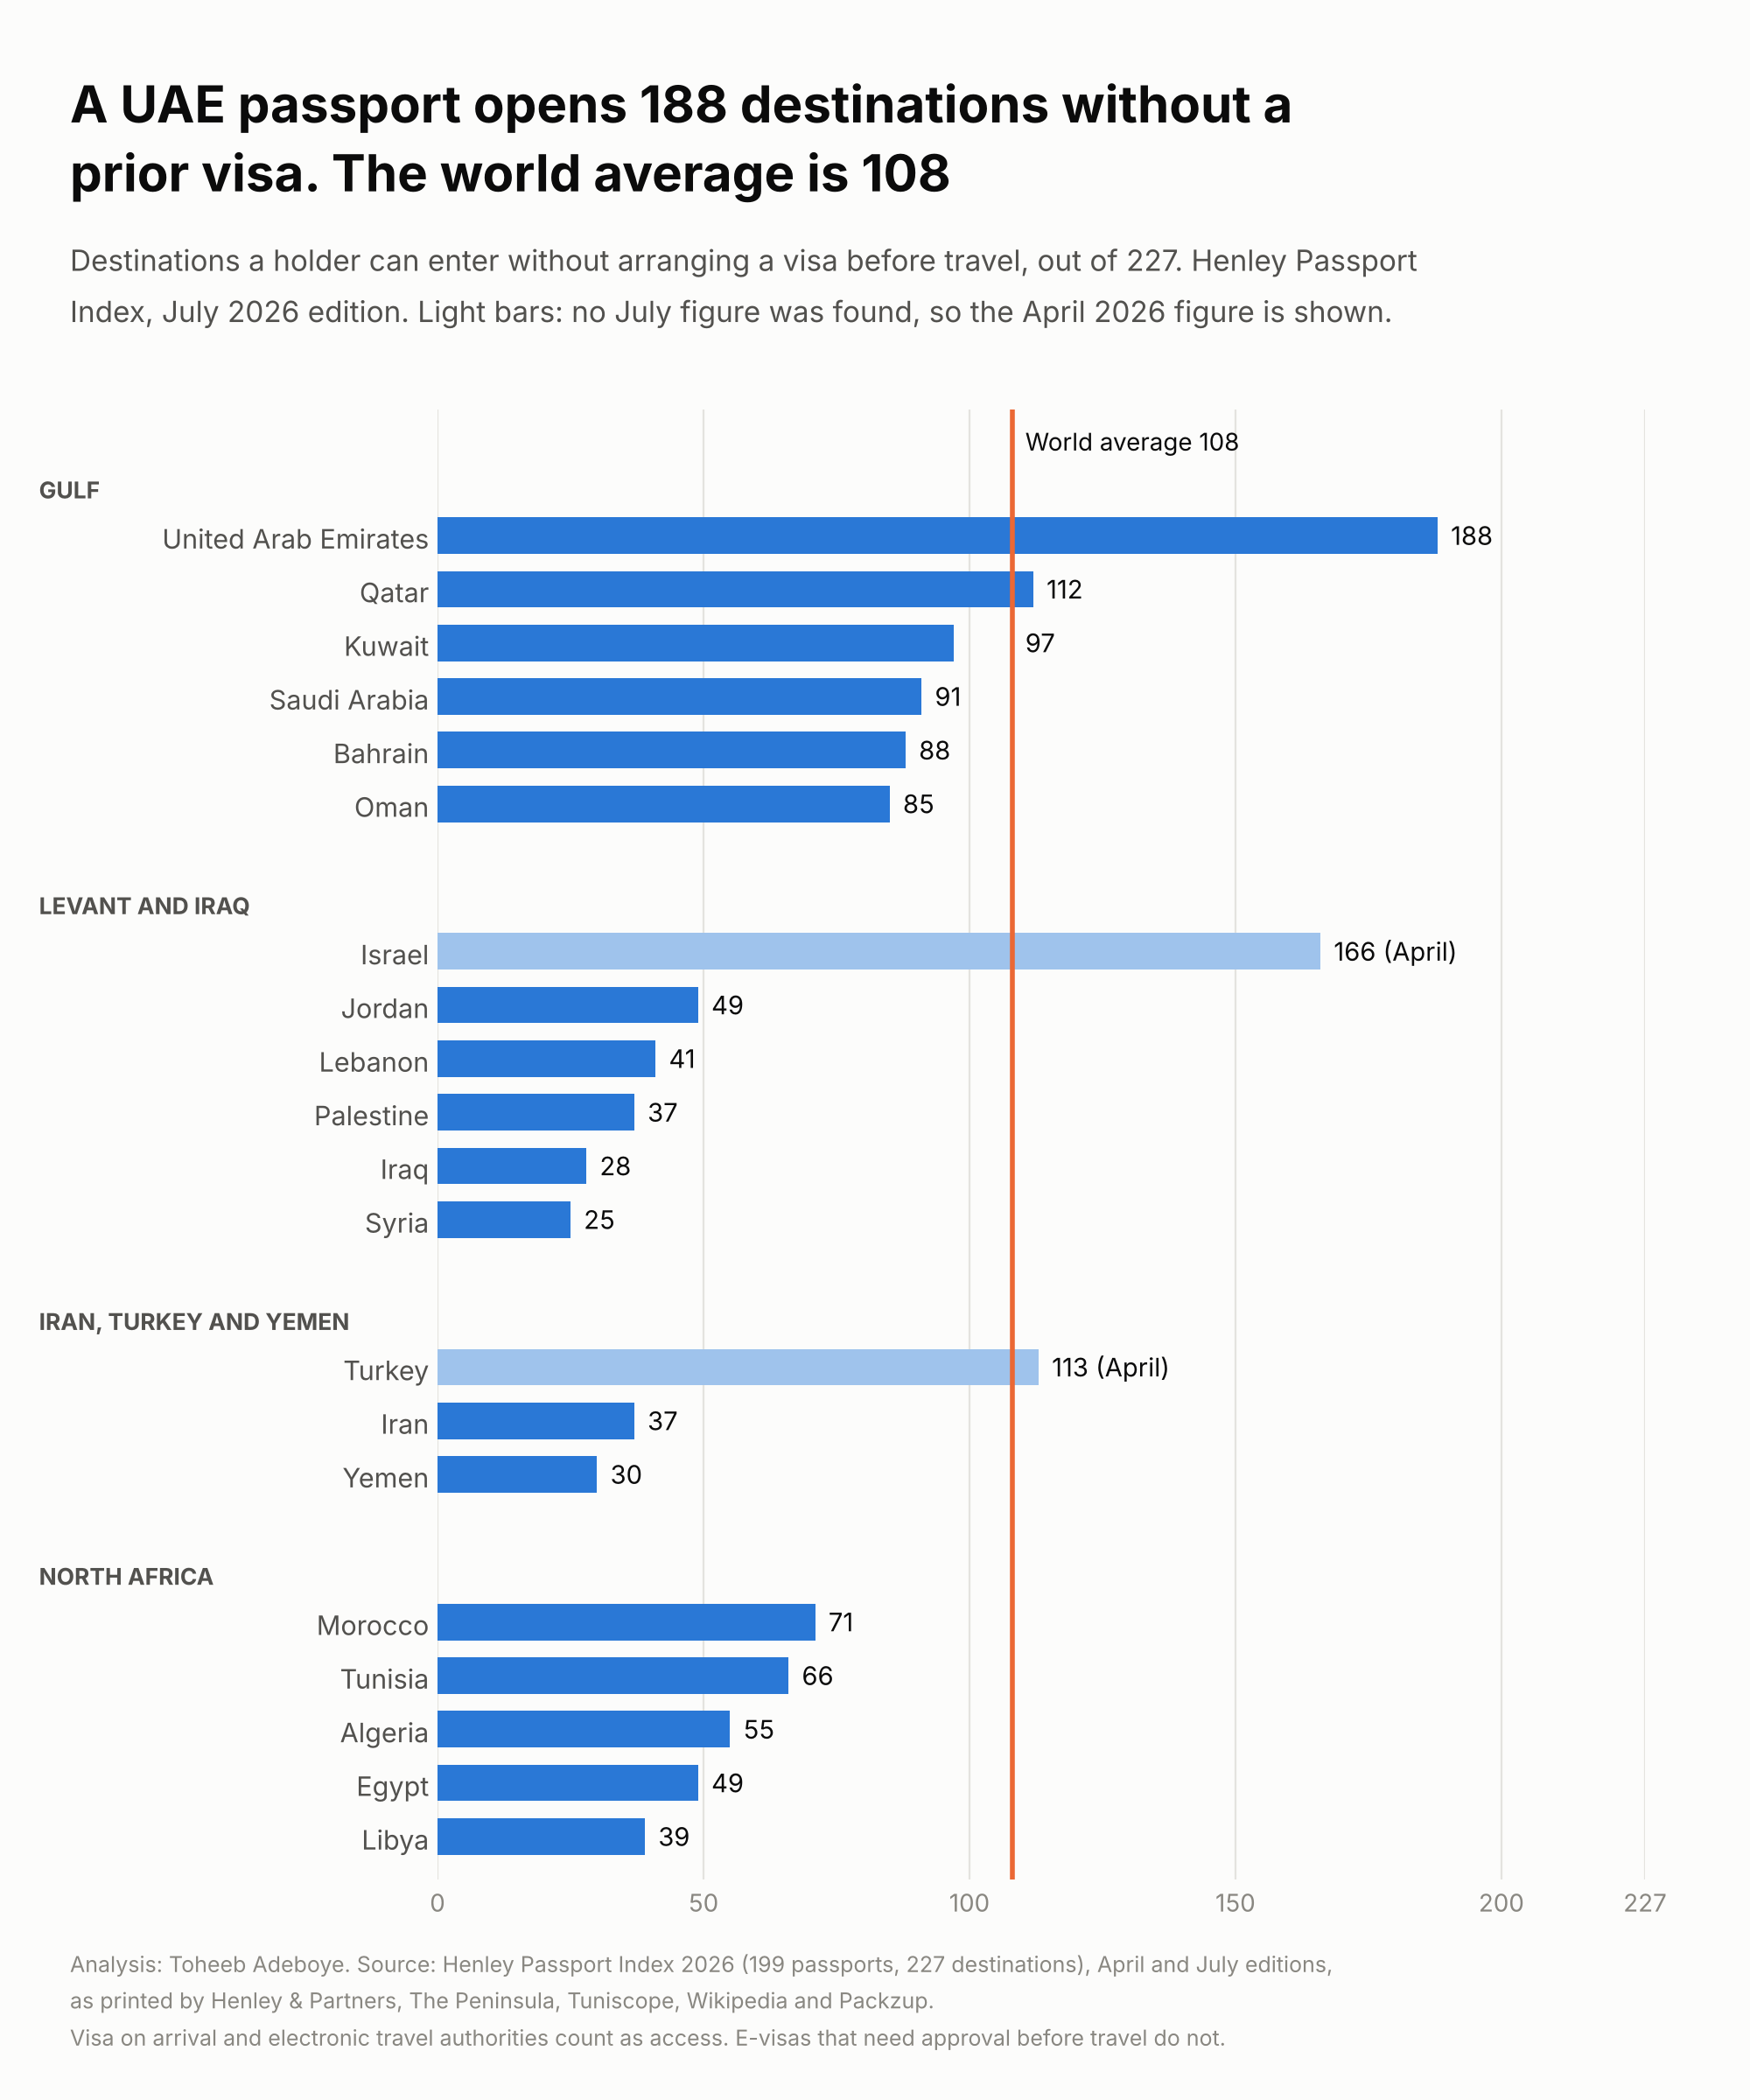

In [8]:
from IPython.display import Image
Image("images/passport-middle-east-chart.png", width=700)

## 7. Regions of the world, Middle East first

In [9]:
order = ["Middle East", "Europe", "Rest of Asia", "Rest of Africa", "North America", "South America", "Oceania"]
reg = tidy.groupby("region").score_apr_2026.agg(passports="count", mean_score="mean", median_score="median", min_score="min", max_score="max").reindex(order)
reg["above_world_mean"] = [int((tidy[tidy.region == r].score_apr_2026 > world_mean).sum()) for r in order]
reg.round(2)

,passports,mean_score,median_score,min_score,max_score,above_world_mean
region,,,,,,
Middle East,20,73.25,60.5,26,187,4
Europe,46,166.76,182.0,77,186,44
Rest of Asia,35,83.74,64.0,23,192,9
Rest of Africa,49,60.57,55.0,32,154,2
North America,23,133.04,145.0,49,182,18
South America,12,127.50,135.5,75,174,8
Oceania,14,122.14,123.5,84,182,10


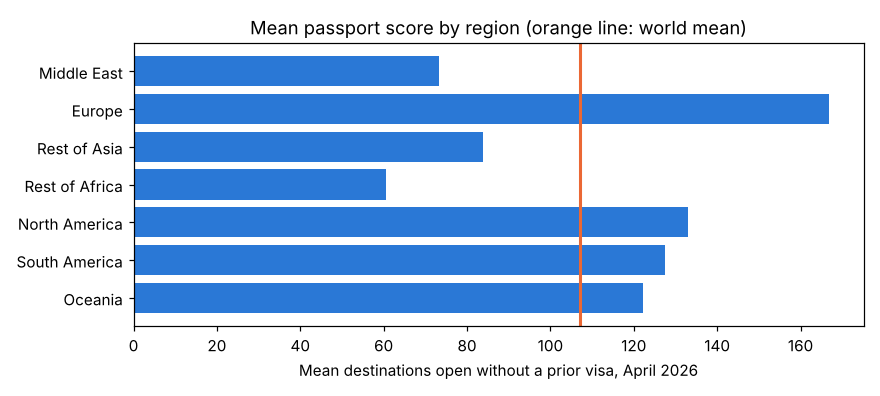

In [10]:
import matplotlib.pyplot as plt
fig, ax = plt.subplots(figsize=(8, 3.6))
ax.barh(order[::-1], reg.mean_score[::-1], color="#2a78d6")
ax.axvline(world_mean, color="#eb6834", lw=2)
ax.set_xlabel("Mean destinations open without a prior visa, April 2026")
ax.set_title("Mean passport score by region (orange line: world mean)")
plt.tight_layout()
plt.show()

## 8. Sensitivity

Two choices could move the result: which figure is used for Bangladesh, and which edition is used for the Middle East.

In [11]:
alt = apr.copy()
alt.loc[alt.country == "Bangladesh", "score_apr_2026"] = 34
print("world mean with Bangladesh at 36:", world_mean, "| at 34:", round(alt.score_apr_2026.mean(), 2))
latest = me.latest_score
print("Middle East mean on April figures:", round(me.score_apr_2026.mean(), 2), "| on the latest figure for each passport:", round(latest.mean(), 2))
print("above 108 on the latest figures:", int((latest > 108).sum()), "of 20")
print("largest April to July change in the Middle East:", int(me.change_apr_to_jul.abs().max()), "destinations")

world mean with Bangladesh at 36: 107.21 | at 34: 107.2
Middle East mean on April figures: 73.25 | on the latest figure for each passport: 73.35
above 108 on the latest figures: 4 of 20
largest April to July change in the Middle East: 4 destinations


## 9. Recompute and compare with the build script output

In [12]:
summary = pd.read_csv("data/processed/region_summary.csv").set_index("group")
for r in order:
    assert abs(summary.loc[r, "mean_score"] - round(tidy[tidy.region == r].score_apr_2026.mean(), 2)) < 1e-9
assert abs(summary.loc["World", "mean_score"] - world_mean) < 1e-9
assert abs(summary.loc["Gulf", "mean_score"] - round(gulf.score_apr_2026.mean(), 2)) < 1e-9
check = apr.merge(tidy, on="country")
assert len(check) == 199 and (check.score_apr_2026_x == check.score_apr_2026_y).all() and (check.rank_printed == check.rank_apr_2026).all()
jcheck = jul.merge(tidy, on="country")
assert (jcheck.score_jul_2026_x == jcheck.score_jul_2026_y).all() and len(jcheck) == int(tidy.score_jul_2026.notna().sum())
headline = {"UAE July": 188, "Qatar July": 112, "Kuwait July": 97, "Saudi Arabia July": 91, "Bahrain July": 88, "Oman July": 85}
got = dict(zip(gulf.country.replace({"United Arab Emirates": "UAE"}) + " July", gulf.score_jul_2026.astype(int)))
assert got == headline, got
print("all recomputed figures equal the build script output")

all recomputed figures equal the build script output
